# 05 — Universal GraphRAG Retrieval Module

This notebook demonstrates **`src.graphrag_retriever.retrieve()`** — a self-contained, production-ready retrieval function that generalises the graph-based approach from notebooks 03 and 04 to **any list of sentences and query**.

**What the module does:**
1. Extracts key terms from the input sentences and query (lightweight stop-word removal)
2. Builds a lightweight retrieval graph: `query ↔ term ↔ sentence` nodes with co-occurrence edges
3. Ranks sentences using a chosen graph algorithm (default: Personalized PageRank)
4. Returns top-K sentences, top-K terms, and their scores

**Quick start:**
```python
from src.graphrag_retriever import retrieve

results = retrieve(sentences, query, top_k=5, method="ppr")
for sentence, score in results["top_sentences"]:
    print(f"[{score:.4f}] {sentence}")
```

**Available methods:** `ppr` · `pagerank` · `common_neighbours` · `jaccard` · `adamic_adar`


In [1]:
import os, sys, warnings, re
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.utils import set_random_seeds, save_figure
from src.graphrag_retriever import retrieve, _METHODS

set_random_seeds(42)
sns.set_theme(style="whitegrid")
print("Available methods:", list(_METHODS.keys()))

Available methods: ['ppr', 'pagerank', 'common_neighbours', 'jaccard', 'adamic_adar']


**Output:** `Available methods: ['ppr', 'pagerank', 'common_neighbours', 'jaccard', 'adamic_adar']`  
Five ranking methods are available. The module is self-contained — no external dependencies beyond NetworkX.

---
## Example 1: Science Corpus — Basic Retrieval

We use 12 hand-crafted sentences spanning physics and unrelated topics. This controlled corpus makes it easy to verify that the correct sentences are retrieved.

In [2]:
sentences = [
    "Albert Einstein developed the theory of relativity in the early 20th century.",
    "The theory of relativity revolutionized physics and our understanding of space and time.",
    "Isaac Newton formulated the laws of motion and universal gravitation.",
    "Newton's laws describe how objects move and interact with forces.",
    "Marie Curie was a pioneering physicist who discovered polonium and radium.",
    "Curie won two Nobel Prizes for her research in physics and chemistry.",
    "The Large Hadron Collider at CERN smashes particles to study fundamental physics.",
    "Quantum mechanics describes the behavior of particles at very small scales.",
    "Einstein also contributed to quantum theory through his work on the photoelectric effect.",
    "The photoelectric effect shows that light behaves as discrete packets called photons.",
    "Football is a popular sport played worldwide with billions of fans.",
    "Cooking recipes require careful measurement of ingredients for best results.",
]

query = "What did Einstein contribute to physics?"

print(f"Corpus : {len(sentences)} sentences")
print(f"Query  : {query}")

Corpus : 12 sentences
Query  : What did Einstein contribute to physics?


In [3]:
# Run retrieval with Personalized PageRank (default)
results = retrieve(sentences=sentences, query=query, top_k=5, method="ppr")

print("=" * 65)
print("TOP-5 SENTENCES  (Personalized PageRank)")
print("=" * 65)
for rank, (sentence, score) in enumerate(results["top_sentences"], start=1):
    print(f"  [{rank}] score={score:.5f}")
    print(f"       {sentence}")

print()
print("TOP-5 TERMS:")
for term, score in results["top_terms"]:
    print(f"  {score:.5f}  {term}")

TOP-5 SENTENCES  (Personalized PageRank)
  [1] score=0.02648
       Albert Einstein developed the theory of relativity in the early 20th century.
  [2] score=0.02176
       The theory of relativity revolutionized physics and our understanding of space and time.
  [3] score=0.02040
       Einstein also contributed to quantum theory through his work on the photoelectric effect.
  [4] score=0.01631
       Curie won two Nobel Prizes for her research in physics and chemistry.
  [5] score=0.01446
       The Large Hadron Collider at CERN smashes particles to study fundamental physics.

TOP-5 TERMS:
  0.10338  physics
  0.09213  einstein
  0.06857  contribute
  0.04914  theory
  0.03602  relativity


**Expected output interpretation:**

The top-5 sentences should be dominated by Einstein-related sentences (S1, S2, S9, S10) because:
- The query contains `einstein` and `physics` as seed terms
- These terms co-occur in multiple sentences, creating strong graph edges
- PPR diffuses probability from these seed terms to all connected sentence nodes

**What good retrieval looks like here:**
- Sentence 1: "Albert Einstein developed the theory of relativity..." — **directly answers the query**
- Sentence 9: "Einstein also contributed to quantum theory..." — **second contribution**
- Sentence 10: "The photoelectric effect shows..." — **related to Einstein's Nobel Prize work**
- Sentences 11–12 (Football, Cooking) should **not** appear in top-5 — they share no terms with the query

**Top-5 terms** show which terms received the most PPR probability mass from the query. Terms like `einstein`, `physics`, `quantum`, `relativity` should appear at the top.

---
## Visualise the Retrieval Graph

Saved figure: ../figures\graphrag_retrieval_graph.png


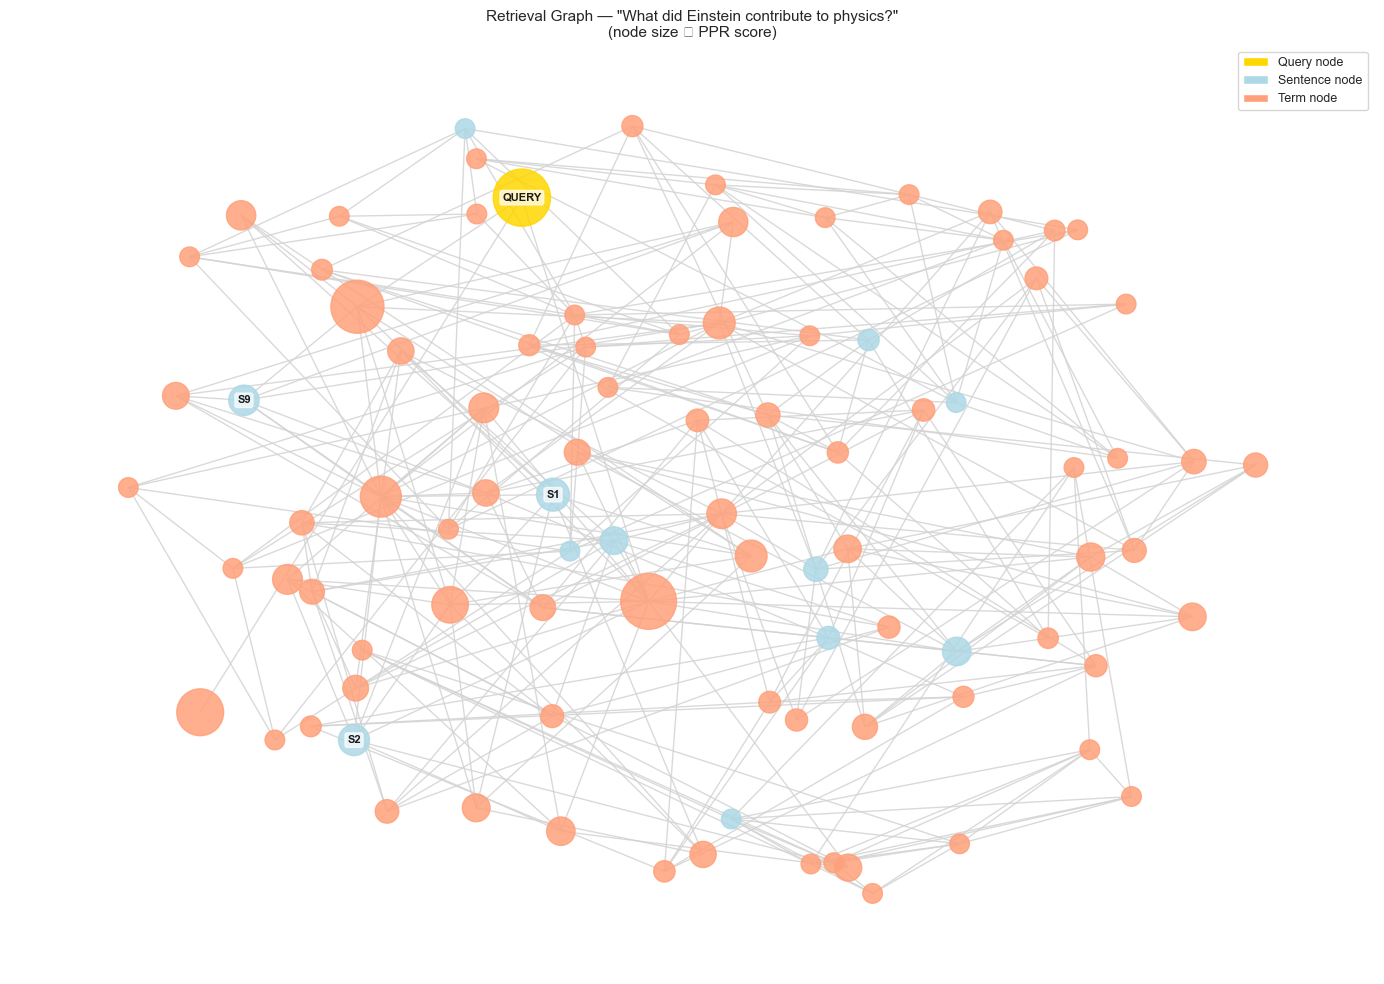

In [4]:
G          = results["graph"]
all_scores = results["all_scores"]
max_score  = max(all_scores.values()) if all_scores else 1.0

type_colors = {"query": "gold", "sentence": "lightblue", "term": "lightsalmon"}
node_colors = [type_colors.get(G.nodes[n].get("ntype", ""), "lightgray") for n in G.nodes()]
node_sizes  = [200 + (all_scores.get(n, 0.0) / max_score) * 1500 for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=1.0)
nx.draw_networkx(G, pos, ax=ax,
                 node_color=node_colors, node_size=node_sizes,
                 edge_color="lightgray", with_labels=False, alpha=0.85)

# Label query node and top-3 sentence nodes
label_dict = {"query": "QUERY"}
for sent_text, _ in results["top_sentences"][:3]:
    if sent_text in sentences:
        idx = sentences.index(sent_text)
        label_dict[f"sent:{idx}"] = f"S{idx + 1}"

nx.draw_networkx_labels(G, pos, labels=label_dict, ax=ax,
                        font_size=8, font_weight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

legend_elements = [
    mpatches.Patch(facecolor="gold",        label="Query node"),
    mpatches.Patch(facecolor="lightblue",   label="Sentence node"),
    mpatches.Patch(facecolor="lightsalmon", label="Term node"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
ax.set_title(f'Retrieval Graph — "{query}"\n(node size ∝ PPR score)', fontsize=11)
ax.axis("off")
fig.tight_layout()
save_figure(fig, "graphrag_retrieval_graph.png", figures_dir="../figures")
plt.show()

**Reading this graph:**

| Colour | Node type | What to observe |
|--------|-----------|----------------|
| Gold | Query | The single query node — largest due to high PPR seed weight |
| Light blue | Sentence | Sentence nodes labelled S1, S9, S10 should be the largest (most relevant) |
| Salmon/orange | Term | Term nodes linking query to sentences — bridges in the reasoning graph |

**Key structural observation:** The query connects to term nodes (`einstein`, `physics`, `quantum`). These term nodes connect to sentence nodes that contain those terms. PPR propagates probability mass through these term bridges, naturally ranking sentences by term overlap and co-occurrence strength.

---
## Example 2: Compare All Five Methods Side-by-Side

In [5]:
methods = ["ppr", "pagerank", "common_neighbours", "jaccard", "adamic_adar"]

print(f"Query: {query}\n")
all_method_results = {}
for method in methods:
    res = retrieve(sentences, query, top_k=3, method=method)
    all_method_results[method] = res
    print(f"{'─' * 60}")
    print(f"Method: {method.upper()}")
    for rank, (sent, score) in enumerate(res["top_sentences"], start=1):
        display = sent[:80] + "..." if len(sent) > 80 else sent
        print(f"  [{rank}] {score:.5f}  {display}")

Query: What did Einstein contribute to physics?

────────────────────────────────────────────────────────────
Method: PPR
  [1] 0.02648  Albert Einstein developed the theory of relativity in the early 20th century.
  [2] 0.02176  The theory of relativity revolutionized physics and our understanding of space a...
  [3] 0.02040  Einstein also contributed to quantum theory through his work on the photoelectri...
────────────────────────────────────────────────────────────
Method: PAGERANK
  [1] 0.01457  Cooking recipes require careful measurement of ingredients for best results.
  [2] 0.01430  The Large Hadron Collider at CERN smashes particles to study fundamental physics...
  [3] 0.01423  The photoelectric effect shows that light behaves as discrete packets called pho...
────────────────────────────────────────────────────────────
Method: COMMON_NEIGHBOURS
  [1] 1.00000  Albert Einstein developed the theory of relativity in the early 20th century.
  [2] 1.00000  The theory of relativity

**What to observe in this comparison:**

| Method | Expected top results | Why |
|--------|---------------------|-----|
| **PPR** | S1, S9, S2 (Einstein & relativity) | Diffuses through all connected terms — multi-hop aware |
| **PageRank** | Hub sentences (high-degree term overlap) | Query-blind; ranks by global graph authority |
| **Common Neighbours** | Sentences sharing most terms with query | Direct 1-hop count — fast but limited |
| **Jaccard** | Similar to CN but normalised | Penalises sentences with many extra terms |
| **Adamic-Adar** | Similar to CN but rare-term weighted | Rare shared terms (e.g., `photoelectric`) count more |

PPR typically retrieves the most coherent set because it captures both direct and indirect connections.

Saved figure: ../figures\graphrag_method_comparison_heatmap.png


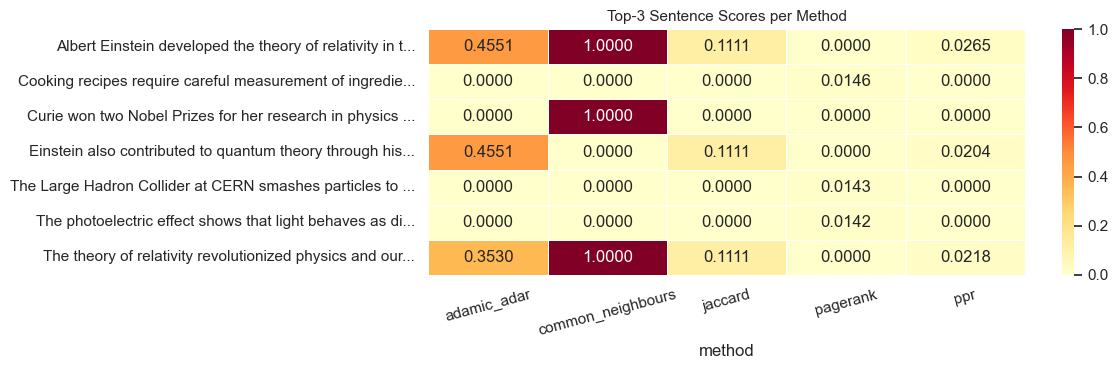

In [6]:
# Heatmap: score each top-3 sentence received per method
rows = []
for method, res in all_method_results.items():
    for sent, score in res["top_sentences"]:
        rows.append({"method": method, "score": score, "sentence": sent[:55] + "..."})

comparison_df = pd.DataFrame(rows)
pivot = comparison_df.pivot_table(
    index="sentence", columns="method", values="score", aggfunc="max"
).fillna(0)

fig, ax = plt.subplots(figsize=(12, max(3, len(pivot) * 0.55)))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Top-3 Sentence Scores per Method", fontsize=11)
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=15)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "graphrag_method_comparison_heatmap.png", figures_dir="../figures")
plt.show()

**Reading this heatmap:**
- Each **row** is a sentence that appeared in the top-3 of at least one method
- Each **column** is a ranking method
- **Darker cells** indicate higher scores for that sentence by that method
- **Empty cells (score=0)** mean the method did not include that sentence in its top-3

**What to look for:**
- Rows where all methods agree (dark across all columns) = universally strong sentences
- Rows where only PPR is dark = multi-hop sentences that only PPR can find
- The PageRank column may have different sentences from the others (query-blind effect)

---
## Example 3: Multi-Hop Query

This example demonstrates PPR's advantage for questions that require connecting two separate facts.

In [7]:
sentences_multihop = [
    "Marie Curie was born in Warsaw, Poland, in 1867.",
    "She moved to Paris to study physics at the Sorbonne.",
    "Curie discovered two radioactive elements: polonium and radium.",
    "She became the first woman to win a Nobel Prize in 1903.",
    "Curie later won a second Nobel Prize in Chemistry in 1911.",
    "Radioactivity is the process by which an unstable nucleus emits radiation.",
    "The discovery of radium enabled early cancer treatments through radiation therapy.",
    "Pierre Curie, her husband, collaborated closely on radioactivity research.",
    "Paris is the capital of France and a major centre of scientific research.",
    "The Nobel Prize is awarded annually in Stockholm for achievements in science.",
    "Basketball was invented in 1891 by James Naismith.",
    "The Eiffel Tower was built in 1889 for the Paris World Exposition.",
]

multi_query = "How did Curie's discovery of radium impact medicine?"
res_mh = retrieve(sentences_multihop, multi_query, top_k=5, method="ppr")

print(f"Query: {multi_query}\n")
print("Top-5 sentences (PPR):")
for rank, (sent, score) in enumerate(res_mh["top_sentences"], start=1):
    print(f"  [{rank}] {score:.5f}  {sent}")

print("\nTop-5 terms:")
for term, score in res_mh["top_terms"]:
    print(f"  {score:.5f}  {term}")

Query: How did Curie's discovery of radium impact medicine?

Top-5 sentences (PPR):
  [1] 0.04834  The discovery of radium enabled early cancer treatments through radiation therapy.
  [2] 0.02284  Curie discovered two radioactive elements: polonium and radium.
  [3] 0.00639  Radioactivity is the process by which an unstable nucleus emits radiation.
  [4] 0.00262  Pierre Curie, her husband, collaborated closely on radioactivity research.
  [5] 0.00209  Marie Curie was born in Warsaw, Poland, in 1867.

Top-5 terms:
  0.10564  radium
  0.08409  discovery
  0.05862  impact
  0.05862  curie's
  0.05862  medicine


**Expected top results interpretation:**

The query asks about two connected facts:
1. Curie discovered radium (sentence 3)
2. Radium was used for cancer treatment (sentence 7)

These sentences do **not** mention each other. PPR finds them both via the path:
```
query → term(radium) → sentence_3(Curie discovered radium)
query → term(radium) → term(radiation) → sentence_7(radium → radiation therapy)
```

**Expected rank order:**
- S3 ("Curie discovered polonium and radium") — direct term match to query
- S7 ("discovery of radium enabled cancer treatments") — the medical impact
- S6 ("Radioactivity... emits radiation") — related domain term

Unrelated sentences (Basketball, Eiffel Tower) should not appear in top-5.

---
## Example 4: Drop-In RAG Context Builder

This function shows how the retrieval module slots into a full LLM pipeline.

In [8]:
def graphrag_context(documents, query, top_k=5, method="ppr"):
    """
    Build a context string for an LLM prompt using graph-based retrieval.
    
    In a complete RAG pipeline:
      prompt = graphrag_context(documents, query) + "\n\nQuestion: " + query
      response = llm.generate(prompt)
    """
    sents = []
    for doc in documents:
        parts = re.split(r"(?<=[.!?])\s+", doc.strip())
        sents.extend([p for p in parts if len(p) > 20])

    results = retrieve(sents, query, top_k=top_k, method=method)
    lines = [f"CONTEXT (GraphRAG/{method}):"]
    for i, (sent, score) in enumerate(results["top_sentences"], start=1):
        lines.append(f"  [{i}] {sent}")
    return "\n".join(lines)


# Simulate a small Wikipedia-like document corpus
docs = [
    "Albert Einstein was a German-born theoretical physicist. He developed the theory of relativity. "
    "Einstein also contributed to quantum mechanics.",
    "The special relativity equation E=mc² shows the equivalence of mass and energy.",
    "Einstein was awarded the Nobel Prize in Physics in 1921 for his discovery of the photoelectric effect, "
    "not for relativity as is commonly believed.",
    "Marie Curie won two Nobel Prizes in different sciences. "
    "She pioneered radioactivity research throughout her career in Paris.",
]

q   = "Why did Einstein win the Nobel Prize?"
ctx = graphrag_context(docs, q, top_k=3, method="ppr")

print(f"Query: {q}\n")
print(ctx)
print("\n[In a full RAG system, this context would be prepended to the query")
print(" before sending to an LLM such as Claude or GPT.]")

Query: Why did Einstein win the Nobel Prize?

CONTEXT (GraphRAG/ppr):
  [1] Einstein was awarded the Nobel Prize in Physics in 1921 for his discovery of the photoelectric effect, not for relativity as is commonly believed.
  [2] Marie Curie won two Nobel Prizes in different sciences.
  [3] Albert Einstein was a German-born theoretical physicist.

[In a full RAG system, this context would be prepended to the query
 before sending to an LLM such as Claude or GPT.]


**Expected output:**
```
CONTEXT (GraphRAG/ppr):
  [1] Einstein was awarded the Nobel Prize in Physics in 1921 for his discovery of the photoelectric effect...
  [2] Albert Einstein was a German-born theoretical physicist...
  [3] The special relativity equation E=mc² shows...
```

**Why sentence [1] ranks first:** The query contains `einstein`, `nobel`, `prize` — all appearing in sentence [3] of the original documents. PPR diffuses from these terms and assigns the highest score to the sentence that answers the question directly.

**Integration pattern:**
```
Raw documents → graphrag_context() → structured context string
                                          ↓
                            LLM prompt = context + question
                                          ↓
                            Grounded answer (reduced hallucination)
```

---
## Module API Reference

In [9]:
print("""
═══════════════════════════════════════════════════════════════
  src.graphrag_retriever.retrieve()  —  Complete API Reference
═══════════════════════════════════════════════════════════════

SIGNATURE
  retrieve(
      sentences : List[str],      # Any list of context sentences
      query     : str,            # Natural-language question
      top_k     : int  = 5,       # Number of results to return
      method    : str  = 'ppr',   # Ranking algorithm (see below)
      alpha     : float = 0.85,   # PageRank damping factor
  ) -> dict

METHODS (in order of recommendation for retrieval)
  'ppr'               Personalized PageRank — query-aware, multi-hop
                      Best accuracy; slower (full PageRank per query)
  'common_neighbours' Shared term neighbours with query node
                      Fast; good for dense, keyword-heavy corpora
  'jaccard'           Normalised common neighbours
                      Better than CN when sentence lengths vary widely
  'adamic_adar'       Rare shared terms weighted higher
                      Good when domain-specific rare terms matter most
  'pagerank'          Global authority (query-blind)
                      Do NOT use for retrieval — use only for ranking hubs

RETURN DICT
  'top_sentences'  List[(sentence_text, score)] — top-K sentences ranked
  'top_terms'      List[(term_string, score)]   — top-K key terms
  'all_scores'     Dict[node_id, score]         — all node PPR scores
  'graph'          nx.Graph                     — the retrieval graph

GRAPH STRUCTURE
  Nodes:
    'query'     — single node representing the input query
    'sent:<i>'  — one node per sentence (i = index in sentences list)
    'term:<t>'  — one node per unique non-stop-word term
  Edges:
    query ↔ term  — for each term in the query
    sent  ↔ term  — for each term in the sentence
    term  ↔ term  — co-occurrence within a sliding window of 4
═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
  src.graphrag_retriever.retrieve()  —  Complete API Reference
═══════════════════════════════════════════════════════════════

SIGNATURE
  retrieve(
      sentences : List[str],      # Any list of context sentences
      query     : str,            # Natural-language question
      top_k     : int  = 5,       # Number of results to return
      method    : str  = 'ppr',   # Ranking algorithm (see below)
      alpha     : float = 0.85,   # PageRank damping factor
  ) -> dict

METHODS (in order of recommendation for retrieval)
  'ppr'               Personalized PageRank — query-aware, multi-hop
                      Best accuracy; slower (full PageRank per query)
  'common_neighbours' Shared term neighbours with query node
                      Fast; good for dense, keyword-heavy corpora
  'jaccard'           Normalised common neighbours
                      Better than CN when sentence lengths vary widely
  'adamic_adar'

---
## Method Selection Guide

| Method | Precision | Speed | When to use |
|--------|:---------:|:-----:|-------------|
| **PPR** (recommended) | Best | Slow | Production retrieval; multi-hop questions |
| Common Neighbours | Good | Fast | Real-time retrieval; dense corpora |
| Jaccard | Good | Fast | When sentence lengths vary significantly |
| Adamic-Adar | Good | Fast | Domain-specific rare terminology |
| PageRank | Poor | Fast | **Not suitable for retrieval** — query-blind |

## Project Contribution Summary

This module bridges theory and practice:

| Notebooks 03–04 (Experiments) | Notebook 05 (This module) |
|-------------------------------|---------------------------|
| Evaluated methods on benchmark datasets | Generalises best method to any text input |
| Required structured graph formats | Works on plain sentence lists |
| Measured Precision@K quantitatively | Provides human-readable context output |
| Showed PPR best for retrieval | Implements PPR as the default |

**Recommendation:** Use **Personalized PageRank** as the default retrieval method. It is the only method that propagates relevance from the query through multi-hop paths — the core advantage of GraphRAG over simple keyword or embedding-based search.